# Isolation with migration (IM) model på bavian-data

Jeg har ind til nu modelleret populationer i isolation eller med konstant størrelse. Nu tilpasser jeg en IM model direkte til bavian-data og udvider den med en *ghost-population* for at teste, om der er genetiske spor fra en ukendt eller uddød bavianpopulation.

IM-modellen beskriver en situation, hvor to populationer opstod ved et split fra en fælles forfader, og efterfølgende har haft begrænset genflow. Så den model man ser er:

```
        ancestral
            |
          split (tid T)
         /     \
       pop1    pop2
        ↔  m ↔           (migration efter split)
```

Ghost udvidelse tilføjer en usamplet population, der bidrog genetisk til en af de observerede populationer:

```
        ancestral
         /      \
       ghost   pop2
         \      |
          admix → pop1
```

Ghost populationer er dokumenteret i bavian studier, som har identificeret genetiske bidrag fra populationer, der ikke længere eksisterer eller ikke er samplet. Jeg tester dette eksplicit her. I stedet for SFS bruger jeg her SNP-par med en bestemt fysisk afstand (~5 kb). Hvert par giver information om den joint allel-frekvens ved to nærliggende loci. Dette indeholder information om rekombinationsrate og populationsstruktur, som SFS alene ikke kan give.
Jeg bruger joint probability-grafen fra Notebook 02's afsnit om diskrete observationer. Fremgangsmåden er identisk. Jeg erstatter blot de simulerede data med rigtige genomdata.

In [1]:
# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, PropertySet, set_log_level
)
set_log_level('WARNING')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

## 1. Validering på simulerede data

Inden jeg anvender modellen på bavian-data, validerer jeg den på simulerede data fra msprime med kendte parametre. Hvis jeg kan genfinde de sande parametre, er implementationen korrekt.

In [17]:
import msprime

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

# Sande parametre for simulering 
mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

# Simuler IM-model med msprime
demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
demography.add_population(name="ancestral", initial_size=anc_pop_size)
demography.add_population_split(time=1000, derived=["pop1", "pop2"], ancestral="ancestral")
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("IM_model_derived_counts.csv", index=False)


In [18]:
def pairs_in_range(nums, diff_lo, diff_hi):
    """
    Find alle SNP-par med fysisk afstand i intervallet [diff_lo, diff_hi].
    Returnerer liste af indeks-par.
    """
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs


df = pd.read_csv("IM_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()


,pos1,pos2,count1,count2
0,121835,126784,2,1
1,130693,135293,2,2
2,962978,967549,2,1
3,1645140,1650545,3,4
4,1679198,1684665,1,2


In [19]:
#Fjern overlappende par (par der deler et SNP)
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,121835,126784,2,1
1,130693,135293,2,2
2,962978,967549,2,1
3,1645140,1650545,3,4
4,1679198,1684665,1,2


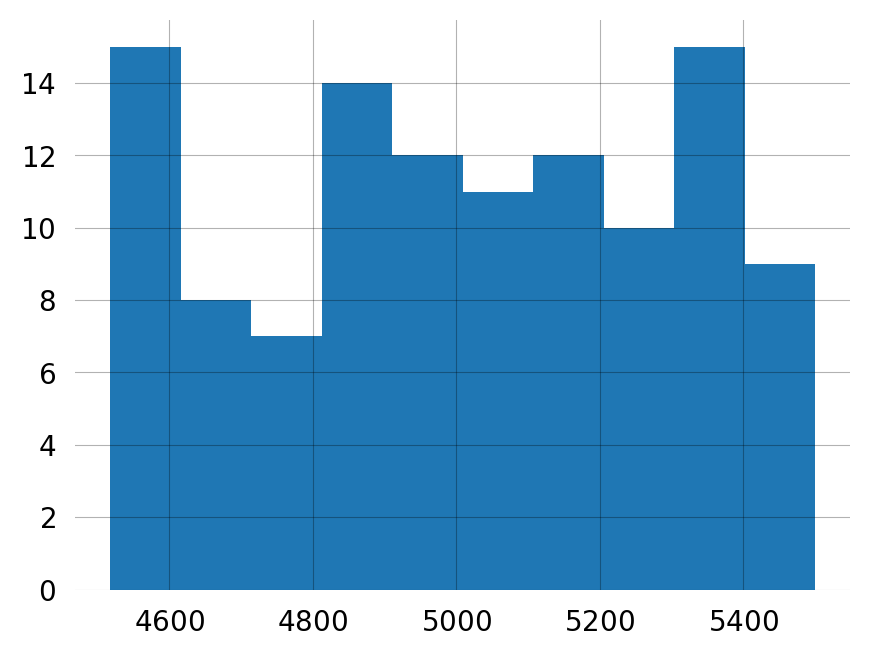

In [20]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [21]:
# Konverter til obersvations-matrix
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [22]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



## 2. Bavian-data

Jeg bruger det fulde kombinerede dataset fra GOG og Filoha som kan ses i notebook 03, alle individer fra begge populationer for at maksimere statistisk styrke i IM analysen.

In [8]:
# Indlæs datasættet
ds = sg.load_dataset("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz")

# Alle GOG og Filoha individer
pop1_ids = [
    'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726',
    'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733',
    'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738', 'PD_0739', 'PD_0740',
    'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'
]  # GOG: P. anubis

pop2_ids = [
    'PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701', 'PD_0702',
    'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
    'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 'PD_0716',
    'PD_0717', 'PD_0718', 'PD_0719'
]  # Filoha: P. hamadryas

keep = pop1_ids + pop2_ids
mask = ds["sample_id"].isin(keep).values
ds_sub = ds.isel(samples=mask)

nr_samples_baboon = ds_sub.dims["samples"]
print(f"GOG:    {len(pop1_ids)} individer")
print(f"Filoha: {len(pop2_ids)} individer")
print(f"Total:  {nr_samples_baboon} individer")


GOG:    25 individer
Filoha: 24 individer
Total:  49 individer


/tmp/ipykernel_2692313/2912886802.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nr_samples_baboon = ds_sub.dims["samples"]


In [9]:
# Beregn derived allele counts
variant_allele_counts = sg.count_variant_alleles(ds_sub)
ac = variant_allele_counts["variant_allele_count"].values
nr_samples_baboon = ds_sub.dims["samples"]

df_baboon = pd.DataFrame({
    "pos":   ds_sub["variant_position"].values,
    "count": ac[:, 1],
}).sort_values("pos").reset_index(drop=True)

# Behold segregerende varianter
df_baboon = df_baboon[(df_baboon["count"] > 0) & (df_baboon["count"] < nr_samples_baboon)]

print(f"Antal segregerende varianter: {len(df_baboon):,}")
print(f"Allel count fordeling:")
print(df_baboon["count"].value_counts().sort_index().to_string())

/tmp/ipykernel_2692313/2505885014.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nr_samples_baboon = ds_sub.dims["samples"]


Antal segregerende varianter: 619,927
Allel count fordeling:
count
1     100358
2      60436
3      45168
4      34815
5      28944
6      25518
7      20571
8      18664
9      16018
10     14913
11     14468
12     12636
13     12218
14     10955
15      9989
16     10970
17      9051
18      8241
19      7899
20      8250
21      7742
22      6752
23      7550
24      7246
25      6585
26      5884
27      5992
28      5595
29      5728
30      5255
31      5698
32      5122
33      5372
34      4892
35      4895
36      6282
37      4560
38      4234
39      4344
40      5045
41      4970
42      4277
43      4285
44      4374
45      4443
46      4328
47      4445
48      3950


In [ ]:
# Udtræk SNP-par med afstand ~5000 bp
pairs_idx_baboon = pairs_in_range(
    df_baboon["pos"].values, distance - tolerance, distance + tolerance
)

pairs_baboon = pd.DataFrame(
    [(df_baboon.at[i,"pos"], df_baboon.at[j,"pos"],
      df_baboon.at[i,"count"], df_baboon.at[j,"count"])
     for i, j in pairs_idx_baboon],
    columns=["pos1", "pos2", "count1", "count2"]
)

# Visualiser afstandsfordelingen for at bekræfte at filteringen er korrekt
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(pairs_baboon.pos2 - pairs_baboon.pos1, bins=20, color='C0', alpha=0.7)
ax.set_xlabel("Afstand mellem SNP-par (bp)")
ax.set_ylabel("Antal par")
ax.set_title("Fordeling af SNP-par afstande")
ax.axvline(distance, color='C1', linestyle='--', label=f'Målafstand: {distance} bp')
ax.legend()
plt.tight_layout()
plt.show()

# Konverter til observations-matrix
n_obs_baboon = len(pairs_baboon)
observations_baboon = np.zeros((n_obs_baboon, nr_samples_baboon), dtype=int)
for i, (c1, c2) in enumerate(pairs_baboon[["count1", "count2"]].values):
    if c1 < nr_samples_baboon: observations_baboon[i, int(c1)] = 1
    if c2 < nr_samples_baboon: observations_baboon[i, int(c2)] = 1

print(f"\nAntal SNP-par: {n_obs_baboon:,}")
print(f"Observations-matrix form: {observations_baboon.shape}")

## 3. IM-model: to populationer med split og migration

Jeg tilpasser nu IM-modellen til bavian-dataene. Modellen har tre parametre:

- **T_split**: Split-tidspunkt (generationer)
- **m12**: Migrationrate fra pop1 til pop2
- **m21**: Migrationrate fra pop2 til pop1

Et positivt migrationssignal indikerer, at GOG og Filoha-populationerne ikke har været i fuldstændig isolation siden splittet, konsistent med observeret hybridisering i felten.

In [ ]:
# IM-model
graph_im = Graph()

graph_im.add_population("pop1")      # GOG
graph_im.add_population("pop2")      # Filoha
graph_im.add_population("ancestral")

graph_im.add_split(
    parent="ancestral",
    children=["pop1", "pop2"],
    time="T_split"
)

graph_im.add_migration("pop1", "pop2", rate="m12")
graph_im.add_migration("pop2", "pop1", rate="m21")

# Priors 
priors_im = PropertySet(
    T_split=GaussPrior(1000, 500),      # Split for ~1000 generationer siden
    m12=HalfCauchyPrior(1e-4),          # Lav migrationrate
    m21=HalfCauchyPrior(1e-4),
)

print("IM-model klar med parametre:")
print("  T_split: split-tidspunkt (generationer)")
print("  m12:     migration GOG → Filoha")
print("  m21:     migration Filoha → GOG")

In [ ]:
# Kør inferens på bavian-data
result_im = graph_im.fit(
    observations=observations_baboon,
    priors=priors_im,
    optimizer=Adam(
        step_size=ExpStepSize(0.05),
        regularization=ExpRegularization(1e-3)
    ),
    steps=500
)

print("=== IM-model resultater ===")
print(result_im)

## 4. Ghost-model: admixture fra ukendt population

Hvis IM-modellen ikke passer godt, kan det indikere tilstedeværelsen af en tredje, ikke-samplet population. Jeg udvider nu modellen med en *ghost-population* en forfaderpopulation der ikke er direkte samplet, men som har bidraget genetisk til en af de observerede populationer.

Modellen tilføjer to nye parametre:

- **T_anc**: Ancestral split-tid (ghost + pop2 skilles fra ancestral)
- **T_admix**: Tidspunkt for admixture fra ghost til pop1
- **p**: Proportionen af pop1's arvemasse der stammer fra pop2 (vs. ghost)

In [ ]:
# Ghost-model
graph_ghost = Graph()

graph_ghost.add_population("pop1")       # GOG
graph_ghost.add_population("pop2")       # Filoha
graph_ghost.add_population("ghost")      # Ukendt population
graph_ghost.add_population("ancestral")

# Ancestral split: ghost og pop2 opstår fra ancestral
graph_ghost.add_split(
    parent="ancestral",
    children=["ghost", "pop2"],
    time="T_anc"
)

# Admixture: pop1 stammer dels fra pop2 (prop. p) og dels fra ghost (1-p)
graph_ghost.add_admixture(
    child="pop1",
    parents=["pop2", "ghost"],
    proportions=["p", "1-p"],
    time="T_admix"
)

# Priors: ghost-split er ældre end admixture
priors_ghost = PropertySet(
    T_anc=GaussPrior(1500, 500),    # Gammel ancestral split
    T_admix=GaussPrior(500, 200),   # Nyere admixture-event
    p=GaussPrior(0.7, 0.2),         # Størstedelen fra pop2, resten fra ghost
)

print("Ghost-model klar med parametre:")
print("  T_anc:   ancestral split (generationer)")
print("  T_admix: admixture fra ghost til pop1 (generationer)")
print("  p:       andel af pop1 fra pop2 (vs. ghost)")

In [ ]:
# Kør inferens
result_ghost = graph_ghost.fit(
    observations=observations_baboon,
    priors=priors_ghost,
    optimizer=Adam(
        step_size=ExpStepSize(0.05),
        regularization=ExpRegularization(1e-3)
    ),
    steps=500
)

print("=== Ghost-model resultater ===")
print(result_ghost)

## 5. Modelsammenligning

Jeg sammenligner de to modeller via *log-likelihood*: den model med højest log-likelihood passer bedst til data. Da ghost-modellen har flere parametre, er en højere log-likelihood ikke automatisk et bevis for ghost-populationen.

In [ ]:
print("Modelsammenligning")
print(f"IM-model log-likelihood:    {result_im.log_likelihood:.2f}")
print(f"Ghost-model log-likelihood: {result_ghost.log_likelihood:.2f}")
print()
delta = result_ghost.log_likelihood - result_im.log_likelihood
print(f"ΔLLK (ghost - IM) = {delta:.2f}")
print()
if delta > 5:
    print("Ghost-modellen passer markant bedre.")
    print("Dette er evidens for en ghost-population i bavianernes historik.")
elif delta > 2:
    print("Ghost-modellen passer noget bedre, men resultatet er tvetydigt.")
else:
    print("Ingen klar forskel. IM-modellen kan ikke afvises.")

In [ ]:
# Visualiser posterior-fordelinger for de vigtigste parametre
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# IM: posterior for split-tid
if hasattr(result_im, 'samples') and 'T_split' in result_im.samples:
    sns.kdeplot(result_im.samples['T_split'], ax=axes[0], label='IM: T_split', color='C0')
axes[0].set_xlabel("Split-tidspunkt (generationer)")
axes[0].set_title("IM-model: posterior for split-tid")
axes[0].legend()

# Ghost: posterior for admixture-tid
if hasattr(result_ghost, 'samples') and 'T_admix' in result_ghost.samples:
    sns.kdeplot(result_ghost.samples['T_admix'], ax=axes[1], label='Ghost: T_admix', color='C1')
    sns.kdeplot(result_ghost.samples['T_anc'],   ax=axes[1], label='Ghost: T_anc',   color='C2')
axes[1].set_xlabel("Tid (generationer)")
axes[1].set_title("Ghost-model: posteriorer for tidspunkter")
axes[1].legend()

plt.tight_layout()
plt.show()

## Opsummering

| Model | Parametre | Hvad den tester |
|---|---|---|
| **IM-model** | $T_{split}$, $m_{12}$, $m_{21}$ | To populationer med split og efterfølgende migration |
| **Ghost-model** | $T_{anc}$, $T_{admix}$, $p$ | Admixture fra en usamplet tredje population |

- Hvis *IM-modellen* passer bedst: GOG og Filoha har en simpel split-og-migration historik, consistent med sekundær kontakt
- Hvis *ghost-modellen* passer bedst: Der er evidens for en ukendt bavian-lineage der har bidraget genetisk. Dette er konsistent med fund fra andre studier af bavianer i Østafrika


I næste notebook 06 afprøver jeg en alternativ model *two-island modellen* som antager konstant migration uden et diskret split-tidspunkt. Dette er en fundamentalt anden demografisk hypotese, og sammenligningen af de to modeller giver os en klarere forståelse af bavianernes historik.